In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [2]:
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
    'income'
]
df = pd.read_csv('../data/adult.data', header=None, names=columns, na_values=' ?')
print(df.shape)
df.head()

(32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
print(df.isnull().sum())

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64


In [4]:
df = df.dropna()
print(df.shape)

(30162, 15)


**Альтернативный способ работы с колонками**: числовые колонки заполнить средним значением, категориальные модой.
`df['age'].fillna(df['age'].mean())`

`df['workclass'].fillna(df['workclass'].mode()[0])`

<Axes: >

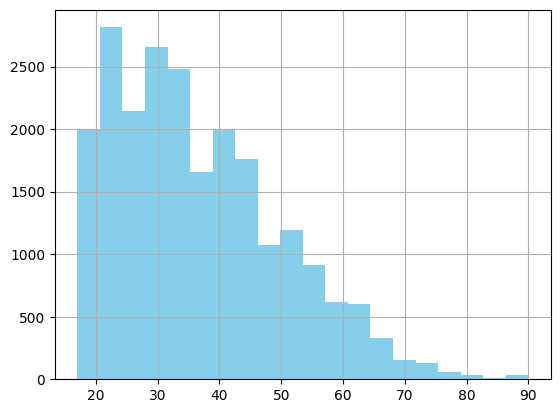

In [5]:
df[df['income'] == ' <=50K']['age'].hist(bins=20, color='skyblue')

<Axes: >

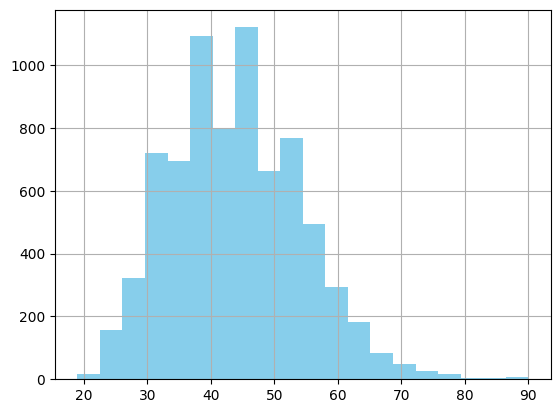

In [6]:
df[df['income'] == ' >50K']['age'].hist(bins=20, color='skyblue')

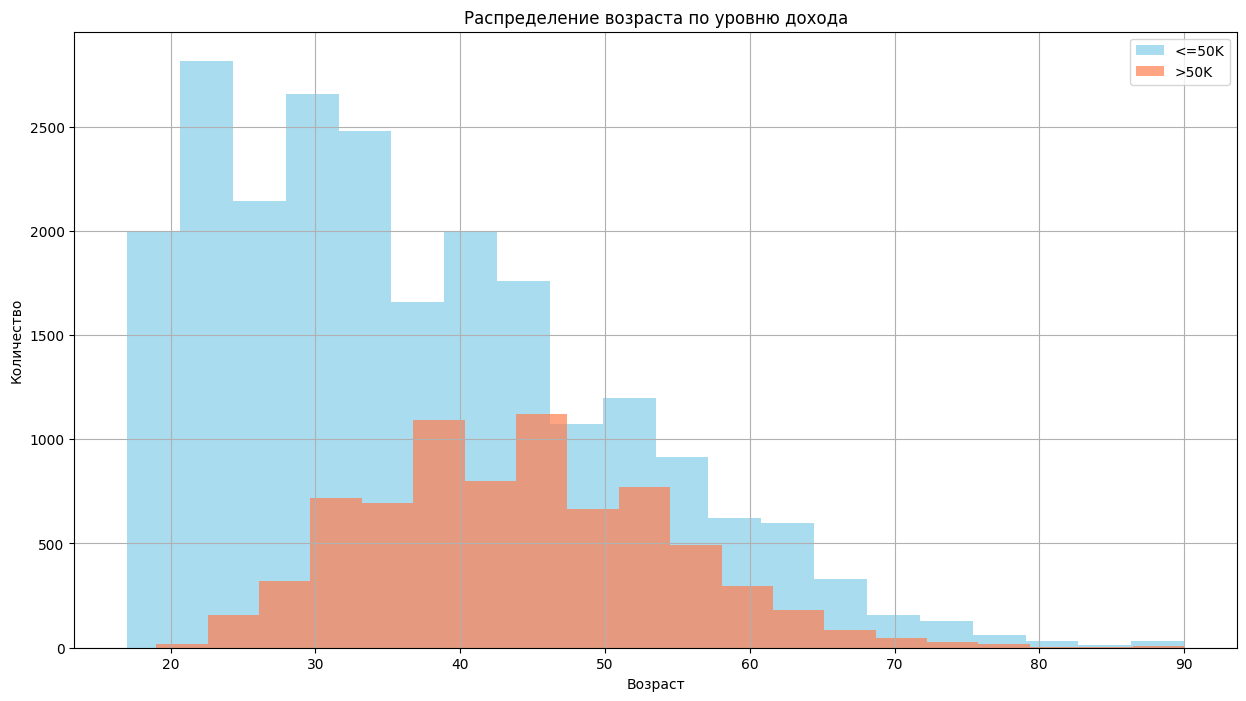

In [7]:
plt.figure(figsize=(15, 8))

df[df['income'] == ' <=50K']['age'].hist(bins=20, color='skyblue', alpha=0.7, label='<=50K')
df[df['income'] == ' >50K']['age'].hist(bins=20, color='coral', alpha=0.7, label='>50K')

plt.title('Распределение возраста по уровню дохода')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.legend()
plt.show()

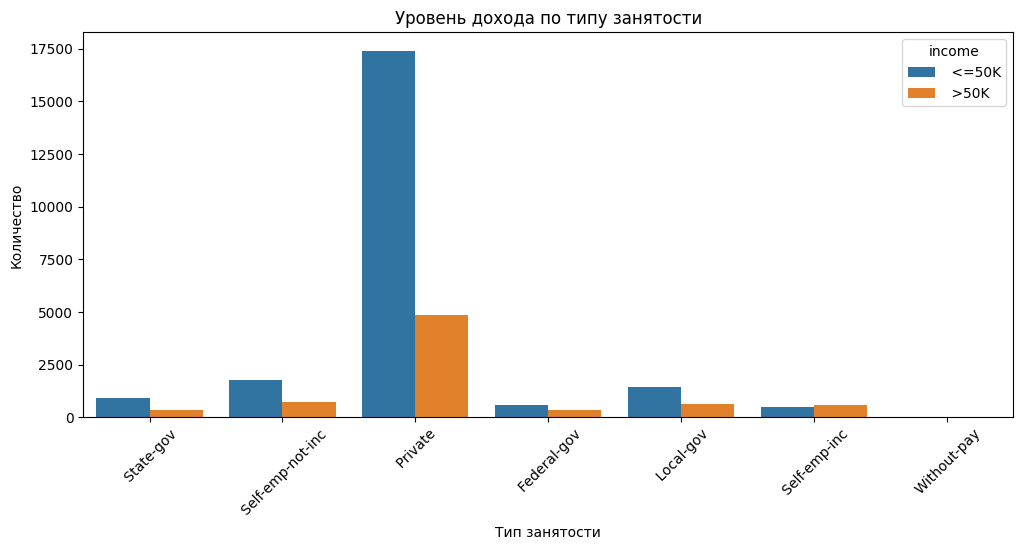

In [8]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='workclass', hue='income')
plt.title('Уровень дохода по типу занятости')
plt.xlabel('Тип занятости')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.show()

In [9]:
df = pd.get_dummies(df, columns=[
    'workclass', 'education', 'marital_status', 
    'occupation', 'relationship', 'race', 
    'sex', 'native_country'
])

print(df.shape)

(30162, 105)


In [10]:
df['income'] = df['income'].map({' <=50K': 0, ' >50K': 1})
df.income.value_counts()

income
0    22654
1     7508
Name: count, dtype: int64

In [11]:
X = df.drop('income', axis=1)
y = df['income']

print(X.shape)
print(y.shape)

(30162, 104)
(30162,)


In [12]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=21 
)

In [13]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

X_train: (24129, 104)
X_val: (6033, 104)


In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

print("Train score:", lr_model.score(X_train_scaled, y_train))
print("Val score:", lr_model.score(X_val_scaled, y_val))

Train score: 0.8502217248953542
Val score: 0.8468423669816012


In [15]:
svm_model = SVC()
svm_model.fit(X_train_scaled, y_train)
print("Train score:", svm_model.score(X_train_scaled, y_train))
print("Val score:", svm_model.score(X_val_scaled, y_val))

Train score: 0.8607484769364665
Val score: 0.8493286921929388


**a)Преобразования данных:**
- Удалены строки с пропусками ( ?) - 2400 строк
- One-Hot Encoding для категориальных признаков - колонок стало 104
- Таргет income преобразован в 0/1
- Данные нормализованы через StandardScaler

**b)Сравнение точности моделей train/val:**
- Логистическая регрессия: 0.850/0.846
- Метод опорных векторов: 0.86/0.849

**c)Справились ли модели с задачей?**
- Да, обе модели показали точность около 85% что является хорошим результатом для бинарной классификации.

Однако классы несбалансированы — людей с доходом <=50K в 3 раза больше. 
Это означает что модель может просто предсказывать <=50K для всех и получить 75% точности.
Также стоит обратить внимание на время: Логистическая регрессия отработала за 1 секунду vs 80 секунд на SVC.

**Что можно улучшить:**
- Попробовать разные solver для логистической регрессии
- Подобрать параметры SVM (C, kernel)
- Решить проблему дисбаланса классов
- Добавить больше признаков или создать новые
